# Lotto Randomness Test

This notebook evaluates how similar the real lotto data is to a fully random drawing process.

The key idea is to compare the real data not with a single random sample, but with the distribution of many Monte Carlo simulations.

Methods used:
1. Monte Carlo simulation to create a random baseline
2. Frequency comparison with a random 95% interval
3. Chi-square test
4. KL divergence
5. Consecutive-draw overlap comparison

### 1. Library Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import (
    ALL_NUMBERS,
    build_random_frequency_interval_frame,
    calculate_consecutive_overlap,
    calculate_kl_divergence,
    calculate_number_frequency,
    simulate_random_frequency_baseline,
    run_chi_square_uniform_test,
    summarize_randomness_results,
)
from src.config import PROCESSED_LOTTO_FILE
from src.visualization import save_report_figure, save_report_table


### 2. Prepare the Data

In [2]:
df = pd.read_csv(PROCESSED_LOTTO_FILE)

df.head()

,row_id,round,n1,n2,n3,n4,n5,n6,bonus,rank_text,winner_count,prize_amount,numbers,sum_main,odd_count,even_count,low_count,high_count
0,1214,1,10,23,29,33,37,40,16,1등,0,0,"10,23,29,33,37,40",172,4,2,1,5
1,1213,2,9,13,21,25,32,42,2,1등,1,2002006800,"9,13,21,25,32,42",142,4,2,3,3
2,1212,3,11,16,19,21,27,31,30,1등,1,2000000000,"11,16,19,21,27,31",125,5,1,4,2
3,1211,4,14,27,30,31,40,42,2,1등,0,0,"14,27,30,31,40,42",184,2,4,1,5
4,1210,5,16,24,29,40,41,42,3,1등,0,0,"16,24,29,40,41,42",192,2,4,1,5


In [3]:
number_cols = ["n1", "n2", "n3", "n4", "n5", "n6"]
real_freq = calculate_number_frequency(df, number_cols=number_cols)
numbers = df[number_cols].values.flatten()
real_freq

1     167
2     152
3     170
4     159
5     153
6     163
7     168
8     156
9     133
10    161
11    164
12    177
13    175
14    170
15    166
16    166
17    169
18    172
19    167
20    168
21    165
22    141
23    147
24    164
25    150
26    164
27    180
28    151
29    153
30    156
31    165
32    141
33    173
34    181
35    161
36    162
37    171
38    169
39    165
40    172
41    147
42    153
43    162
44    161
45    172
Name: count, dtype: int64

### 3. Generate Monte Carlo Baselines

This section repeatedly generates random draws with the same number of rounds as the real dataset.
The result is used as a distributional baseline rather than as a single random example.

In [4]:
# Random simulation helpers are now imported from src.analysis.simulation

In [5]:
n_rounds = len(df)

n_rounds

1217

In [6]:
n_simulations = 2000
freq_matrix, simulated_overlap_means = simulate_random_frequency_baseline(
    n_rounds,
    n_simulations=n_simulations,
    seed=42
)

random_freq = pd.Series(
    freq_matrix.mean(axis=0),
    index=ALL_NUMBERS,
    name="random_mean"
)

random_freq.head()

1    162.1120
2    162.0575
3    162.4915
4    162.2155
5    162.3005
Name: random_mean, dtype: float64

### 4. Real vs. Random Frequency

This section compares the real number frequency with the simulated random mean and the 95% interval.
If most real frequencies stay inside the band, the long-run frequency pattern remains compatible with randomness.

In [7]:
comparison = build_random_frequency_interval_frame(real_freq, freq_matrix, ALL_NUMBERS)
comparison.head(10)

,real,random_mean,random_lower,random_upper,deviation_from_random_mean
1,167,162.1120,138.000,186.000,4.8880
2,152,162.0575,140.000,186.000,-10.0575
3,170,162.4915,139.000,186.000,7.5085
4,159,162.2155,140.000,185.000,-3.2155
5,153,162.3005,139.000,186.000,-9.3005
6,163,162.5960,140.000,185.000,0.4040
7,168,161.8695,139.000,185.000,6.1305
8,156,162.1235,138.975,186.000,-6.1235
9,133,162.6795,141.000,186.000,-29.6795
10,161,162.0470,138.000,186.025,-1.0470


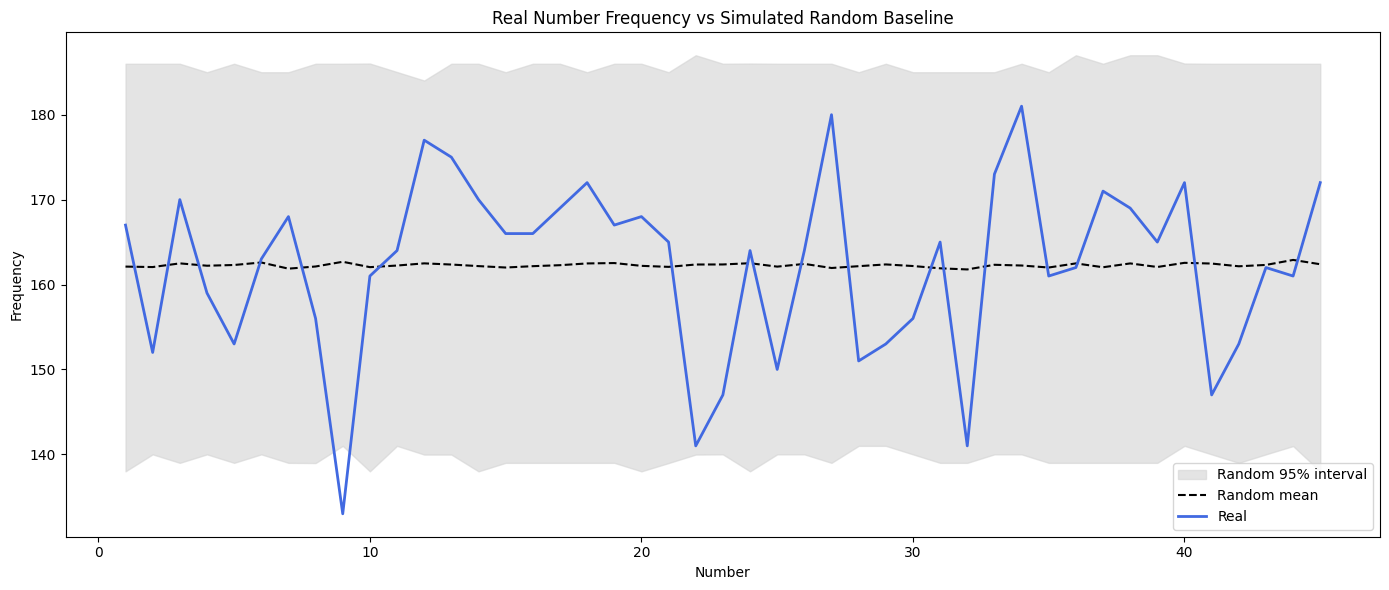

In [8]:
plt.figure(figsize=(14,6))
plt.fill_between(
    comparison.index,
    comparison["random_lower"],
    comparison["random_upper"],
    color="lightgray",
    alpha=0.6,
    label="Random 95% interval"
)
plt.plot(comparison.index, comparison["random_mean"], color="black", linestyle="--", label="Random mean")
plt.plot(comparison.index, comparison["real"], color="royalblue", linewidth=2, label="Real")
plt.title("Real Number Frequency vs Simulated Random Baseline")
plt.xlabel("Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 5. Chi-Square Test

The null hypothesis is that the main-number distribution is uniform.
A sufficiently large p-value means the observed distribution is not clearly distinguishable from uniformity.

Hypotheses

- H_0: The lotto number distribution is uniform.
- H_1: The lotto number distribution is not uniform.

In [9]:
chi_stat, p_value = run_chi_square_uniform_test(real_freq, total_count=numbers.size)
chi_stat, p_value

(29.96795398520953, 0.9473705806070574)

In [10]:
if p_value < 0.05:
    print(f"Reject uniform-frequency null (p={p_value:.4f})")
else:
    print(f"Fail to reject uniform-frequency null (p={p_value:.4f})")

Fail to reject uniform-frequency null (p=0.9474)


### 6. KL Divergence

This section measures the difference between the real distribution and the simulated random mean from an information-theoretic perspective.
Values close to zero indicate that the two distributions are very similar.

This metric quantifies the gap between two probability distributions.

In [11]:
real_prob = real_freq / real_freq.sum()
random_prob = comparison["random_mean"] / comparison["random_mean"].sum()

In [12]:
kl_div = calculate_kl_divergence(real_freq, comparison["random_mean"])
kl_div

0.0020882791942792214

In [13]:
print("KL Divergence: ", kl_div)

KL Divergence:  0.0020882791942792214


### 7. Consecutive-Draw Independence Check

Frequency similarity alone is not enough to claim independence.
This section therefore checks whether the average overlap between consecutive real draws is unusual relative to the simulated random baseline.

In [14]:
actual_draws = df[number_cols].to_numpy()
actual_overlap = calculate_consecutive_overlap(actual_draws)

actual_overlap.describe()

count    1216.000000
mean        0.826480
std         0.786924
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         4.000000
dtype: float64

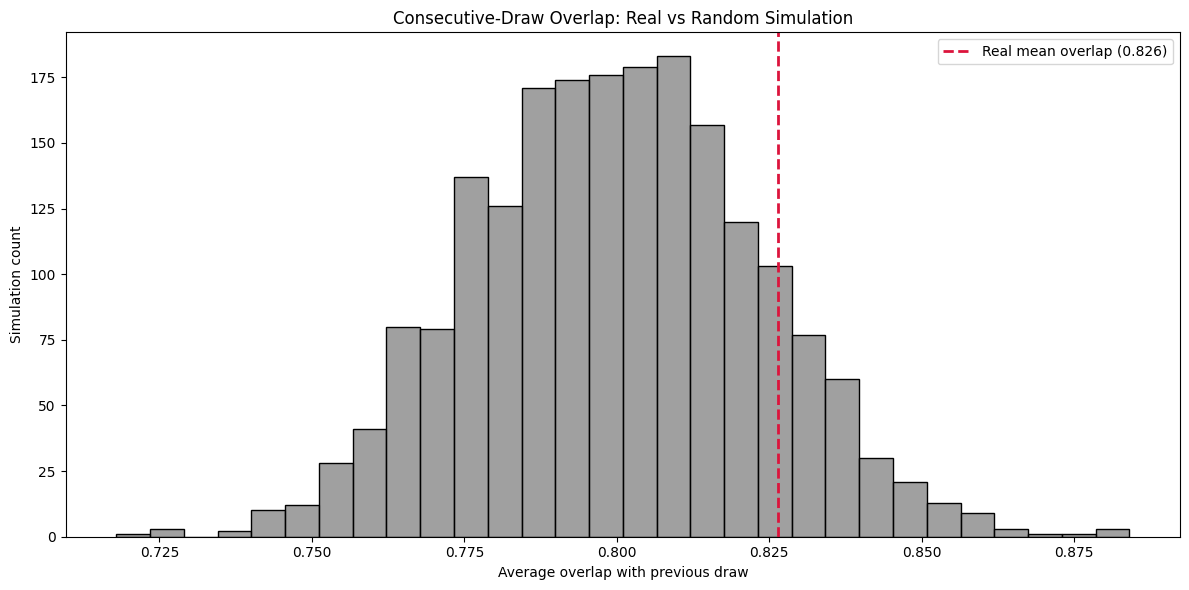

In [15]:
actual_overlap_mean = actual_overlap.mean()

plt.figure(figsize=(12,6))
sns.histplot(simulated_overlap_means, bins=30, color="gray")
plt.axvline(actual_overlap_mean, color="crimson", linestyle="--", linewidth=2, label=f"Real mean overlap ({actual_overlap_mean:.3f})")
plt.title("Consecutive-Draw Overlap: Real vs Random Simulation")
plt.xlabel("Average overlap with previous draw")
plt.ylabel("Simulation count")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
deviation = comparison["deviation_from_random_mean"]

std_dev = deviation.std()

std_dev

np.float64(10.517136543734013)

In [17]:
summarize_randomness_results(
    comparison,
    chi_square_p_value=p_value,
    kl_divergence=kl_div,
    actual_overlap_mean=actual_overlap_mean,
    simulated_overlap_means=simulated_overlap_means,
)

chi_square_p_value                           0.947371
kl_divergence_real_vs_random_mean            0.002088
share_of_numbers_within_random_95pct_band    0.977778
actual_consecutive_overlap_mean              0.826480
random_overlap_mean                          0.799726
empirical_p_value_for_overlap                0.130500
dtype: float64

## Randomness Test Summary

The main interpretation points in this notebook are:

- How many real-number frequencies fall inside the simulated 95% random interval?
- Does the chi-square test reject uniformity?
- Is the KL divergence small enough to suggest close agreement?
- Is the average consecutive-draw overlap unusual relative to the random baseline?

If all four checks remain broadly consistent with the simulated random baseline, the current data does not provide strong evidence that the lotto process is non-independent.

### Report Export


In [18]:
# Save key randomness-test figures and tables for the final report
plt.figure(figsize=(14, 6))
plt.fill_between(
    comparison.index,
    comparison["random_lower"],
    comparison["random_upper"],
    color="lightgray",
    alpha=0.6,
    label="Random 95% interval"
)
plt.plot(comparison.index, comparison["random_mean"], color="black", linestyle="--", label="Random mean")
plt.plot(comparison.index, comparison["real"], color="royalblue", linewidth=2, label="Real")
plt.title("Real Number Frequency vs Simulated Random Baseline")
plt.xlabel("Number")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
save_report_figure(plt.gcf(), "fig_06_real_vs_random_frequency.png")
plt.close(plt.gcf())

plt.figure(figsize=(12, 6))
sns.histplot(simulated_overlap_means, bins=30, color="gray")
plt.axvline(actual_overlap_mean, color="crimson", linestyle="--", linewidth=2, label=f"Real mean overlap ({actual_overlap_mean:.3f})")
plt.title("Consecutive-Draw Overlap: Real vs Random Simulation")
plt.xlabel("Average overlap with previous draw")
plt.ylabel("Simulation count")
plt.legend()
plt.tight_layout()
save_report_figure(plt.gcf(), "fig_06b_consecutive_draw_overlap.png")
plt.close(plt.gcf())

randomness_summary = pd.DataFrame([
    {
        "metric": "chi_square_p_value",
        "value": p_value,
    },
    {
        "metric": "kl_divergence",
        "value": kl_div,
    },
    {
        "metric": "actual_overlap_mean",
        "value": actual_overlap_mean,
    },
    {
        "metric": "deviation_std",
        "value": std_dev,
    },
])

save_report_table(comparison.reset_index().rename(columns={"index": "number"}), "table_04_random_frequency_comparison.csv")
save_report_table(randomness_summary, "table_04_randomness_test_summary.csv")
print("Saved randomness test report artifacts.")


Saved randomness test report artifacts.
